In [27]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vollan, Moser et al. (2025) — Exploring the Processed Brainset

Neuropixels recordings from **MEC** and **hippocampus** in rats during spatial navigation and sleep.

After running `brainsets prepare vollan_moser_alternating_2025`, each session is an `.h5` file containing:
- **`spikes`** — spike timestamps and unit indices (original Kilosort precision)
- **`behavior`** — head position (x, y, z), head direction, theta phase, decoded internal direction (10ms bins, speed-filtered at 5 cm/s)
- **`units`** — unit metadata (brain region, probe, grid cell classification)
- **`domain`** — valid time intervals (gaps where the rat was stationary are removed)

In [28]:
from brainsets.datasets import VollanMoserAlternating2025

## 1. Load the dataset and pick a session

In [29]:
vollan = VollanMoserAlternating2025(
    root="/network/projects/neuro-galaxy/data/processed/"
)
print(f"{len(vollan._recording_ids)} sessions available")
print(vollan._recording_ids[:10], "...")

51 sessions available
['lt_26648_1', 'lt_27764_1', 'lt_27765_2', 'lt_28063_1', 'lt_28229_3', 'lt_28304_1', 'lt_29502_3', 'mmaze_29502_1', 'of_24365_2', 'of_24666_1'] ...


In [30]:
# Pick an open field session with both MEC and HC
session_id = "of_26034_3"
rec = vollan.get_recording(session_id)

print(f"Session: {rec.session.id}")
print(f"Subject: {rec.subject.id} ({rec.subject.species})")
print(f"Task: {rec.session.task}")
print(f"Units: {len(rec.units.id)}")
print(f"Spikes: {rec.spikes.timestamps.shape[0]:,}")

Session: of_26034_3
Subject: 26034 (RATTUS_NORVEGICUS)
Task: NAVIGATION_OPEN_FIELD
Units: 899
Spikes: 2,102,045


## 2. Behavioral data — the rat's trajectory

The behavior timeseries is sampled at 10ms but **speed-filtered**: bins where the rat was below 5 cm/s are removed, leaving gaps in the timestamps.

In [31]:
t = rec.behavior.timestamps[:]
x = rec.behavior.x[:]
y = rec.behavior.y[:]
hd = rec.behavior.hd[:]
theta = rec.behavior.theta[:]
internal_dir = rec.behavior.id[:]

print(f"Time bins: {len(t):,}")
print(f"Time span: {t[0]:.0f} — {t[-1]:.0f} s  ({(t[-1] - t[0]) / 60:.1f} min)")
print(f"Actual sampled time: {len(t) * 0.01 / 60:.1f} min")
print(f"Coverage: {len(t) * 0.01 / (t[-1] - t[0]):.0%}")

Time bins: 140,000
Time span: 5057 — 7891 s  (47.2 min)
Actual sampled time: 23.3 min
Coverage: 49%


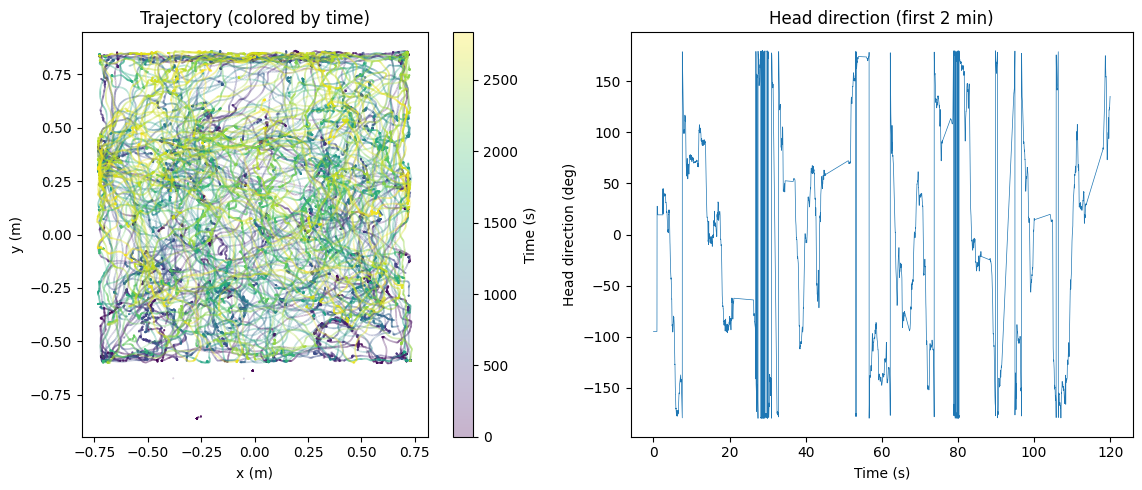

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Trajectory colored by time
sc = axes[0].scatter(x, y, c=t - t[0], s=0.1, alpha=0.3, cmap="viridis")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_title("Trajectory (colored by time)")
axes[0].set_aspect("equal")
plt.colorbar(sc, ax=axes[0], label="Time (s)")

# Head direction over a 2-minute window
mask = (t >= t[0]) & (t < t[0] + 120)
axes[1].plot(t[mask] - t[0], np.degrees(hd[mask]), lw=0.5)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Head direction (deg)")
axes[1].set_title("Head direction (first 2 min)")

plt.tight_layout()
plt.show()

## 3. Units — MEC and hippocampal neurons

Units are split by brain region. MEC units may be classified as grid cells (`is_grid=1`).

In [33]:
unit_ids = rec.units.id
unit_location = np.array(
    [
        loc.decode() if isinstance(loc, bytes) else str(loc)
        for loc in rec.units.location[:]
    ]
)
unit_is_grid = rec.units.is_grid[:]
unit_mean_rate = rec.units.mean_rate[:]

n_mec = np.sum(unit_location == "mec")
n_hc = np.sum(unit_location == "hc")
n_grid = np.sum(unit_is_grid == 1)

print(f"Total: {len(unit_ids)} units")
print(f"  MEC: {n_mec}  ({n_grid} grid cells)")
print(f"  HC:  {n_hc}")
print(f"Firing rates: {unit_mean_rate.mean():.2f} ± {unit_mean_rate.std():.2f} Hz")

Total: 899 units
  MEC: 659  (179 grid cells)
  HC:  240
Firing rates: 1.67 ± 1.42 Hz


## 4. Spikes — accessing individual units

Spikes are stored as a single sorted array of `(timestamp, unit_index)` pairs. To get spikes for one unit, filter by `unit_index`.

In [34]:
spike_times = rec.spikes.timestamps[:]
spike_units = rec.spikes.unit_index[:]

# Pick a grid cell
grid_idx = np.where((unit_location == "mec") & (unit_is_grid == 1))[0]
example_unit = grid_idx[0]

unit_spikes = spike_times[spike_units == example_unit]
print(
    f"Unit {unit_ids[example_unit]}: {len(unit_spikes):,} spikes, "
    f"mean rate = {unit_mean_rate[example_unit]:.2f} Hz"
)

Unit of_26034_3/mec_146: 1,561 spikes, mean rate = 1.11 Hz


## 5. Theta phase and spikes

Theta oscillations (6-10 Hz) are a dominant rhythm in hippocampus and MEC during navigation. The `theta` field gives the instantaneous theta phase (in radians) at each 10ms behavior bin.

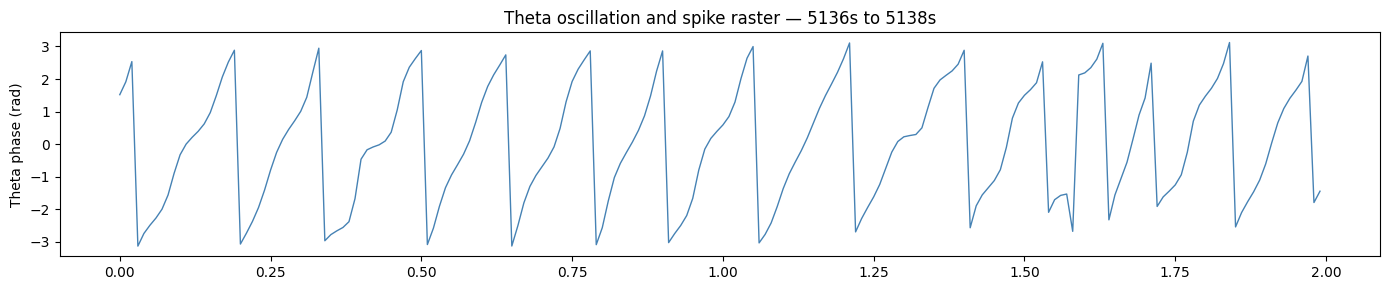

In [39]:
# Show a 2-second window: theta phase + spike raster for a few units
t0 = rec.domain.start[10]  # pick a valid interval
t1 = t0 + 2.0

# Behavior in this window
b_mask = (t >= t0) & (t < t1)
t_win = t[b_mask] - t0
theta_win = theta[b_mask]

# Pick 8 units to show (mix of grid cells and others)
show_units = np.concatenate([grid_idx[:4], np.where(unit_location == "hc")[0][:4]])

fig, ax = plt.subplots(
    1,
    1,
    figsize=(14, 3),
)

# Top: theta phase
ax.plot(t_win, theta_win, color="steelblue", lw=1)
ax.set_ylabel("Theta phase (rad)")
ax.set_title(f"Theta oscillation and spike raster — {t0:.0f}s to {t1:.0f}s")

plt.tight_layout()
plt.show()

### Theta phase preference

Many neurons fire preferentially at specific phases of the theta cycle. We can assign each spike a theta phase by looking up the nearest behavior time bin.

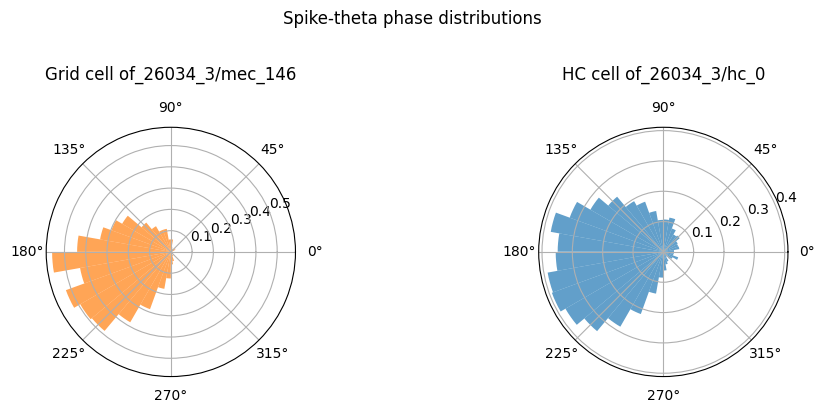

In [40]:
# Assign theta phase to each spike via nearest behavior bin
spike_bin_idx = np.searchsorted(t, unit_spikes) - 1
spike_bin_idx = np.clip(spike_bin_idx, 0, len(t) - 1)
spike_theta = theta[spike_bin_idx]

# Polar histogram of spike theta phases
fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={"projection": "polar"})

# Grid cell
axes[0].hist(spike_theta, bins=36, density=True, alpha=0.7, color="tab:orange")
axes[0].set_title(f"Grid cell {unit_ids[example_unit]}", pad=15)

# A hippocampal cell for comparison
hc_unit = np.where(unit_location == "hc")[0][0]
hc_spikes = spike_times[spike_units == hc_unit]
hc_bin_idx = np.clip(np.searchsorted(t, hc_spikes) - 1, 0, len(t) - 1)
hc_theta = theta[hc_bin_idx]
axes[1].hist(hc_theta, bins=36, density=True, alpha=0.7, color="tab:blue")
axes[1].set_title(f"HC cell {unit_ids[hc_unit]}", pad=15)

plt.suptitle("Spike-theta phase distributions", y=1.02)
plt.tight_layout()
plt.show()

## 6. Binning spikes into firing rates

To align spikes with the behavior timeseries, bin them into the same 10ms time bins. This gives a `(T, N_units)` firing rate matrix.

In [46]:
dt = 0.01  # 10ms bins

# Because the timestamps have gaps (speed-filtered intervals), we can't just
# histogram across the whole array — spikes in gaps would land in the wrong bin.
# Instead, bin within each contiguous interval and concatenate.

domain_starts = rec.domain.start[:]
domain_ends = rec.domain.end[:]

all_counts = []
all_bin_times = []
for ds, de in zip(domain_starts, domain_ends):
    # Behavior bins in this interval
    interval_mask = (t >= ds) & (t < de)
    t_interval = t[interval_mask]
    if len(t_interval) == 0:
        continue

    # Bin edges for this contiguous segment
    edges = np.concatenate([t_interval - dt / 2, [t_interval[-1] + dt / 2]])

    # Spikes in this interval
    s_mask = (unit_spikes >= edges[0]) & (unit_spikes < edges[-1])
    counts, _ = np.histogram(unit_spikes[s_mask], bins=edges)
    all_counts.append(counts)
    all_bin_times.append(t_interval)

firing_rate = np.concatenate(all_counts) / dt
bin_timestamps = np.concatenate(all_bin_times)

print(f"Firing rate shape: {firing_rate.shape}")
print(f"Bin timestamps shape: {bin_timestamps.shape} (same as behavior: {t.shape})")
print(f"Mean rate: {firing_rate.mean():.2f} Hz, Max: {firing_rate.max():.0f} Hz")

Firing rate shape: (140000,)
Bin timestamps shape: (140000,) (same as behavior: (140000,))
Mean rate: 1.11 Hz, Max: 200 Hz


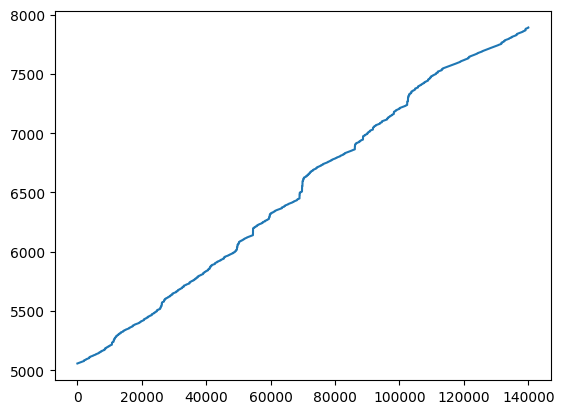

In [48]:
plt.plot(bin_timestamps)

## 7. Spatial tuning — grid cell rate maps

Grid cells fire at regularly-spaced locations forming a hexagonal lattice. We can visualize this by making a 2D firing rate map: spike count per spatial bin divided by occupancy time.

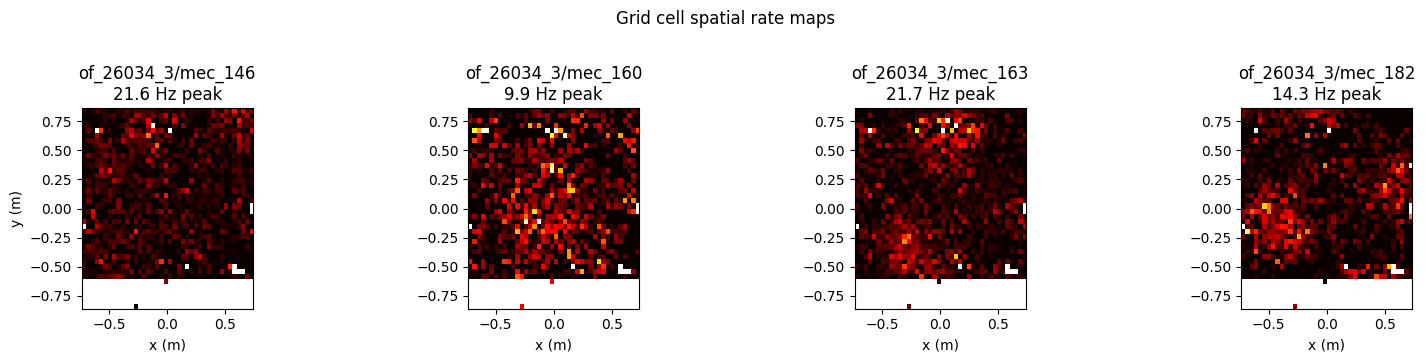

In [42]:
# Show rate maps for 4 grid cells
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
n_spatial_bins = 40
x_edges = np.linspace(x.min(), x.max(), n_spatial_bins + 1)
y_edges = np.linspace(y.min(), y.max(), n_spatial_bins + 1)

# Occupancy map (shared across all units)
occupancy, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
occupancy *= dt  # seconds

for ax, uid in zip(axes, grid_idx[:4]):
    u_spikes = spike_times[spike_units == uid]
    # Map spikes to spatial bins via behavior timestamps
    idx = np.clip(np.searchsorted(t, u_spikes) - 1, 0, len(t) - 1)
    spike_map, _, _ = np.histogram2d(x[idx], y[idx], bins=[x_edges, y_edges])

    rate_map = np.full_like(occupancy, np.nan)
    valid = occupancy > 0.1
    rate_map[valid] = spike_map[valid] / occupancy[valid]

    im = ax.imshow(
        rate_map.T,
        origin="lower",
        aspect="equal",
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        cmap="hot",
    )
    ax.set_title(f"{unit_ids[uid]}\n{rate_map[valid].max():.1f} Hz peak")
    ax.set_xlabel("x (m)")

axes[0].set_ylabel("y (m)")
plt.suptitle("Grid cell spatial rate maps", y=1.02)
plt.tight_layout()
plt.show()

## 8. Population raster with theta overlay

A combined view: theta phase on top, population spike raster below, for a short time window. This shows how population firing relates to the theta rhythm.

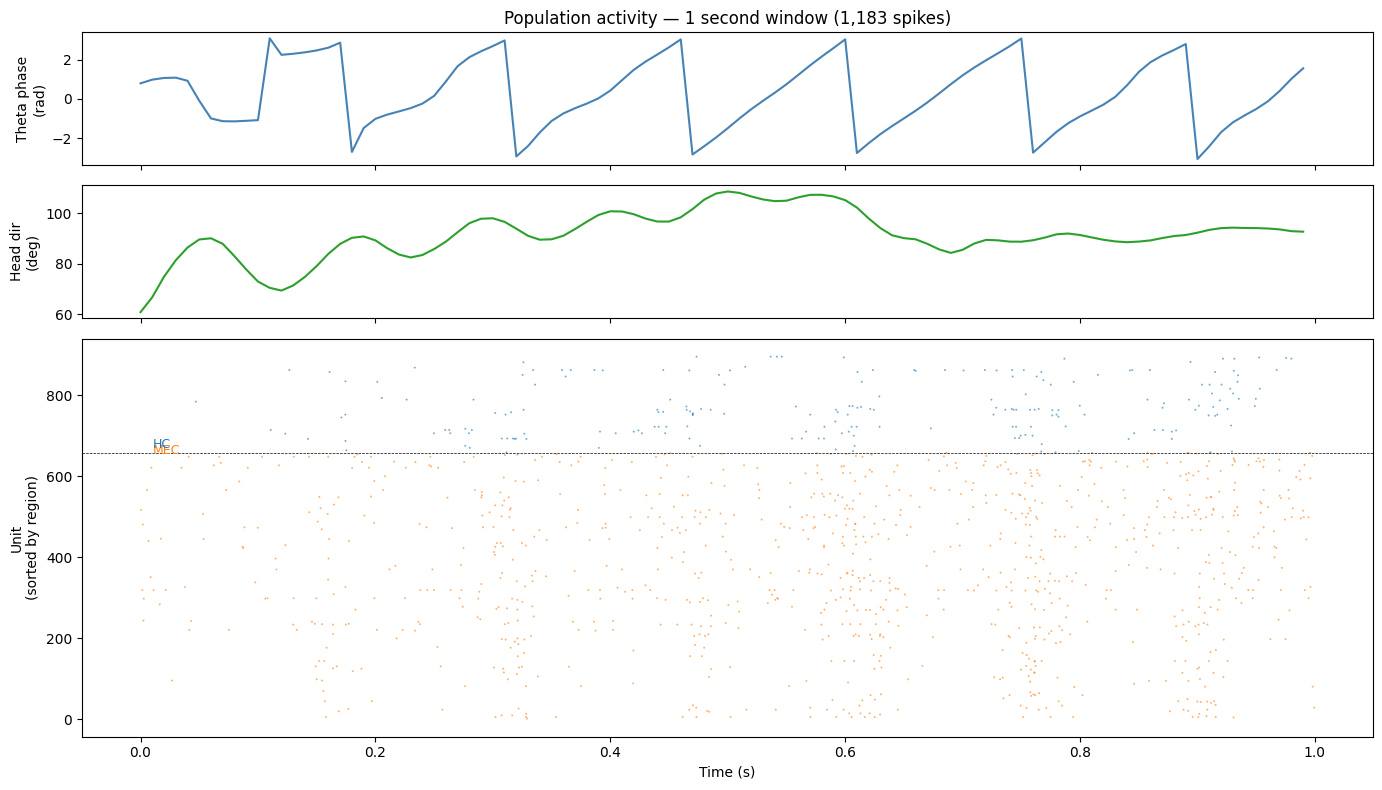

In [43]:
# 1-second window showing all spikes, theta, and position
t0 = rec.domain.start[15]
t1 = t0 + 1.0

fig, axes = plt.subplots(
    3, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [1, 1, 3]}
)

b_mask = (t >= t0) & (t < t1)
t_win = t[b_mask] - t0

# Top: theta phase
axes[0].plot(t_win, theta[b_mask], color="steelblue", lw=1.5)
axes[0].set_ylabel("Theta phase\n(rad)")

# Middle: head direction
axes[1].plot(t_win, np.degrees(hd[b_mask]), color="tab:green", lw=1.5)
axes[1].set_ylabel("Head dir\n(deg)")

# Bottom: full population raster (subsample to keep it fast)
# Sort: MEC units first, then HC
mec_mask = unit_location == "mec"
hc_mask = unit_location == "hc"
sort_order = np.concatenate([np.where(mec_mask)[0], np.where(hc_mask)[0]])
rank = np.zeros(len(unit_ids), dtype=int)
for r, uid in enumerate(sort_order):
    rank[uid] = r

s_mask = (spike_times >= t0) & (spike_times < t1)
s_t = spike_times[s_mask] - t0
s_u = spike_units[s_mask]

colors = np.where(mec_mask[s_u], "tab:orange", "tab:blue")
axes[2].scatter(s_t, rank[s_u], s=2, c=colors, alpha=0.6, linewidths=0)
axes[2].axhline(mec_mask.sum() - 0.5, color="black", lw=0.5, ls="--")
axes[2].set_ylabel("Unit\n(sorted by region)")
axes[2].set_xlabel("Time (s)")
axes[2].text(0.01, mec_mask.sum() - 5, "MEC", fontsize=9, color="tab:orange")
axes[2].text(0.01, mec_mask.sum() + 10, "HC", fontsize=9, color="tab:blue")

axes[0].set_title(f"Population activity — 1 second window ({s_mask.sum():,} spikes)")
plt.tight_layout()
plt.show()

## 9. Using `rec.spikes.slice()` for time windows

The `LazyIrregularTimeSeries` supports `.slice(start, end)` to efficiently get spikes within a time window without loading the entire array.

In [44]:
# Slice spikes from the first valid interval
start, end = rec.domain.start[0], rec.domain.end[0]
interval_spikes = rec.spikes.slice(start, end)

print(f"Interval: {start:.1f} — {end:.1f}s ({end - start:.1f}s)")
print(f"Spikes in interval: {interval_spikes.timestamps.shape[0]:,}")
print(f"Active units: {len(np.unique(interval_spikes.unit_index)):,}")

Interval: 5057.4 — 5061.0s (3.6s)
Spikes in interval: 4,566
Active units: 642
